In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams.update({"font.family": "serif",
                     "font.serif": ["Times New Roman"],
                     "font.size": 10,
                     "lines.linewidth": 1})
from scipy.ndimage import gaussian_filter
import pandas as pd
import os
import glob
import re
from matplotlib.ticker import FuncFormatter
ROOT = os.getcwd()
OUTPUT = os.path.join(ROOT, 'output')
FIGURES = os.path.join(ROOT, 'figures')
for _p in (
    os.path.join(OUTPUT, 'Bifurcations'),
    os.path.join(OUTPUT, 'trajectories_flow'),
    os.path.join(OUTPUT, 'score'),
    os.path.join(OUTPUT, 'score_trajectories'),
    os.path.join(FIGURES, 'Paper'),
):
    os.makedirs(_p, exist_ok=True)



In [2]:
def floating_axes(ax):
    
    # Hide all default spines
    for s in ax.spines.values():
        s.set_visible(False)

    # Floating bottom axis
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_position(('axes', -0.05))

    # Floating left axis
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('axes', -0.05))

AMblue = plt.cm.get_cmap("viridis")(0.4)

In [3]:
# Folder path where the CSV files are stored
directory = os.path.join(OUTPUT, 'score')
directory_simple = os.path.join(OUTPUT, 'Bifurcations')
directory_trajectories = os.path.join(OUTPUT, 'score_trajectories')

# Line tension for change between lense & furrow

In [4]:
main_branch = pd.read_csv(os.path.join(directory_simple, 'Main_branch.csv'), header=None)

diff = abs(main_branch[1] - (main_branch[0] - main_branch[0]**2))
idx_min = diff.idxmin()
zeta_change = main_branch.loc[idx_min, 2]

# Functions

In [5]:
A_M_vals = np.linspace(0, 1, 1000)
A_C_vals = np.linspace(0, 0.5, 1000)

A_M_grid, A_C_grid = np.meshgrid(A_M_vals, A_C_vals)

# Masking invalid geometries
mask = (A_C_grid > 0) & (A_C_grid < A_M_grid) & (A_C_grid < (1 - A_M_grid))


# Perfect sphere condition
sphere = A_M_vals - A_M_vals**2 # RuntimeWarning due to forbidden geometries (A_C < 0 | A_C > A_M | A_C > 1 - A_M)

In [6]:
# Create a formatter that divides by zeta_change
def zeta_formatter(x, pos):
    return f"{x / zeta_change:.2f}"

# Function to create contour plot
def plot_contour(ax, df, xlabel, cbar_label = False):
    df_pivot = df.pivot(index=1, columns=0, values=2) # Score

    X, Y = np.meshgrid(df_pivot.columns, df_pivot.index)
    Z = df_pivot.values
    
    Z_smooth = gaussian_filter(Z, sigma=1)
    contour = ax.contourf(X, Y, Z_smooth, levels=50, cmap='viridis')
    
    for cf in contour.collections:
        cf.set_rasterized(True)

    cbar = plt.colorbar(contour, ax=ax, orientation = 'horizontal', location = 'top')
    
    vmin, vmax = cbar.mappable.get_clim()
    cbar.set_ticks(np.linspace(vmin, vmax, 3))
    cbar.solids.set_rasterized(True)
    cbar.set_label("Disposal efficiency $\mathcal{S}$", fontweight = 'bold')
    
    # Round colorbar ticks to 2 decimal places
    cbar.set_ticks(np.round(cbar.get_ticks(), 2))
    
    ax.set_xlabel(xlabel, fontweight = 'bold')
    ax.yaxis.set_major_formatter(FuncFormatter(zeta_formatter))

# Plotting Efficiencies

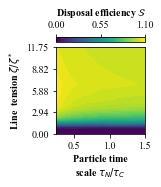

In [14]:
asize = 1/200 # the free energy is rescaled by a/A; therefore, zeta, kappa, are rescaled by a/A; t_a, t_n by the inverse

# --- Figure 1: Heatmap ---
fig, ax = plt.subplots(figsize=(1.6, 2))  # Adjust size for a single plot

# Load and plot the heatmap
file_path = os.path.join(directory, 'Score_t_n.csv')
df = pd.read_csv(file_path, header=None)
df[1] = df[1]/asize # zeta was rescaled by a/A in Matlab
df[2] = df[2].astype(str).str.extract(r'([+-]?\d+(?:\.\d+)?)')[0].astype(float)
df.loc[df[2]>50,2]=0
plot_contour(ax, df, 'Particle time\n'+r'scale $\tau_N/\tau_C$')
ax.set_ylabel(r"Line  tension $\zeta/\zeta^*$", fontweight = 'bold')
    
# Save plot
plt.savefig(os.path.join(FIGURES, 'Paper', 't_nu.svg'), dpi=300)
plt.show()
plt.close(fig)

In [15]:
file_path = os.path.join(directory, 'Score_t_n.csv')
df = pd.read_csv(file_path, header=None)
df[df[2]==max(df[2])]

,0,1,2,3,4
27,0.25,10.8,1.0996,0.0,0.0


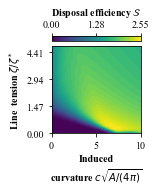

In [65]:
# --- Figure 1: Heatmap ---
fig, ax = plt.subplots(figsize=(1.6, 2))  # Adjust size for a single plot

# Load and plot the heatmap
file_path = os.path.join(directory, 'Score_c.csv')
df = pd.read_csv(file_path, header=None)
df[1] = df[1]/asize # zeta was rescaled by a/A in Matlab
plot_contour(ax, df, 'Induced\n' + r"curvature $c\sqrt{A/(4\pi)}$")
ax.set_ylabel(r"Line  tension $\zeta/\zeta^*$", fontweight = 'bold')

# Save plot
plt.savefig(os.path.join(FIGURES, 'Paper', 'c.svg'), dpi=300)
plt.show()
plt.close(fig)

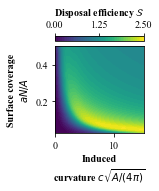

In [66]:
asize = 1/200 # the free energy is rescaled by a/A; therefore, zeta, kappa, are rescaled by a/A; t_a, t_n by the inverse

# --- Figure 1: Heatmap ---
fig, ax = plt.subplots(figsize=(1.6, 2))  # Adjust size for a single plot

# Load and plot the heatmap
file_path = os.path.join(directory, 'Score_n_c.csv')
df = pd.read_csv(file_path, header=None)

df_pivot = df.pivot(index=0, columns=1, values=2) # Score

X, Y = np.meshgrid(df_pivot.columns, df_pivot.index)
Z = df_pivot.values

Z_smooth = gaussian_filter(Z, sigma=1)
contour = ax.contourf(X, Y, Z_smooth, levels=50, cmap='viridis')

for cf in contour.collections:
    cf.set_rasterized(True)

cbar = plt.colorbar(contour, ax=ax, orientation = 'horizontal', location = 'top')

vmin, vmax = cbar.mappable.get_clim()
cbar.set_ticks(np.linspace(vmin, vmax, 3))
cbar.solids.set_rasterized(True)
cbar.set_label("Disposal efficiency $\mathcal{S}$", fontweight = 'bold')

# Round colorbar ticks to 2 decimal places
cbar.set_ticks(np.round(cbar.get_ticks(), 2))

ax.set_xlabel("Induced\n"+r"curvature $c \sqrt{A/(4\pi)}$", fontweight = 'bold')
ax.set_ylabel("Surface coverage\n"+r"$aN/A$", fontweight = 'bold')
plt.savefig(os.path.join(FIGURES, 'Paper', 'c_N.svg'))

In [18]:
file_path = os.path.join(directory, 'Score_n_c.csv')
df = pd.read_csv(file_path, header=None)
df[df[2]==max(df[2])]

,0,1,2,3,4
99,0.0345,14.4,2.6721,0.0,0.0


# Plot trajectories 

In [19]:
# Potting trajectories for particles, plotting score
def plot_trajectory_in_n(ax, ax_score, df, N, alpha):
    a_m_line, = ax.plot(df[0].values, df[1].values, color = AMblue, alpha=alpha)
    nu_f_line, = ax.plot(df[0].values, 2*df[3].values/N, color = 'red', linestyle = '--', alpha=alpha)
    nu_d_line, = ax.plot(df[0].values, (1-2*df[4].values/N), color = 'red', linestyle = '-.', alpha=alpha)
    
    ax.set_xlabel("Time", fontweight = 'bold')
    ax.set_ylabel("Score variables", fontweight = 'bold')
    
    # Plot score
    score_line, = ax_score.plot(df[0].values, df[5].values, color='black', alpha=alpha)
    
    ax_score.set_ylabel(r"Score $s$", fontweight = 'bold')
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax_score.set_yticks([])
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)  
    
    return [a_m_line, nu_f_line, nu_d_line, score_line]

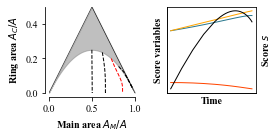

In [20]:
N=1/2
Nf=N/2
Nd=N/2

fig, ax = plt.subplots(1, 2, figsize=(4, 2))

upper_bound = np.minimum(np.where(A_M_vals <= 0.5, A_M_vals, 1 - A_M_vals), 0.5)
ax[0].fill_between(A_M_vals, sphere, upper_bound, color='grey', alpha = 0.5, zorder = 1)
    
    
# Add black diagonal lines
ax[0].plot(np.linspace(0, 0.5, 1000), np.linspace(0, 0.5, 1000), lw=0.5, color='black')
ax[0].plot(np.linspace(0.5, 1, 1000), 1 - np.linspace(0.5, 1, 1000), lw=0.5, color='black')
ax[0].plot(np.linspace(0, 1, 1000), np.zeros(1000), lw=0.5, color='black')

ax[0].set_xlabel('Main area $A_M/A$', fontweight = 'bold')
ax[0].set_ylabel('Ring area $A_C/A$', fontweight = 'bold')
ax[0].set_xlim([0,1])
ax[0].set_ylim([0,0.5])
ax[0].set_aspect(2)

floating_axes(ax[0])

# Plot trajectories
pattern = os.path.join(directory_trajectories, "Traj_fixed_init_A*.csv")

# Find all matching CSV files
csv_files = glob.glob(pattern)

counter = 0

for file in csv_files:
    df = pd.read_csv(file, header = None)
    
    if counter == 2:
        ax[0].plot(df[1].values, df[2].values, color='red', linestyle='--')
        ax_score = ax[1].twinx()
        ax[1].plot(df[0].values, df[1].values, color=AMblue)
        ax[1].plot(df[0].values, df[3].values/Nf, color='orange')
        ax[1].plot(df[0].values, 1-df[4].values/Nd, color='orangered')
        ax_score.plot(df[0].values, df[5].values, color='black')
        ax[1].set_ylabel('Score variables', fontweight='bold')
        ax_score.set_ylabel(r'Score $s$', fontweight='bold')
        
    else:
        ax[0].plot(df[1].values, df[2].values, color='black', linestyle='--')
        
    counter += 1

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

ax[1].set_xlabel('Time', fontweight='bold')
ax[1].set_xticks([])
ax[1].set_yticks([])
ax_score.set_yticks([])
ax_score.set_xticks([])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'Paper', 'traj_description.svg'), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

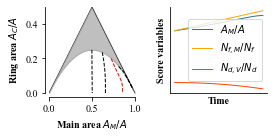

In [9]:
N=1/2
Nf=N/2
Nd=N/2

fig, ax = plt.subplots(1, 2, figsize=(4, 2))

upper_bound = np.minimum(np.where(A_M_vals <= 0.5, A_M_vals, 1 - A_M_vals), 0.5)
ax[0].fill_between(A_M_vals, sphere, upper_bound, color='grey', alpha = 0.5, zorder = 1)
    
    
# Add black diagonal lines
ax[0].plot(np.linspace(0, 0.5, 1000), np.linspace(0, 0.5, 1000), lw=0.5, color='black')
ax[0].plot(np.linspace(0.5, 1, 1000), 1 - np.linspace(0.5, 1, 1000), lw=0.5, color='black')
ax[0].plot(np.linspace(0, 1, 1000), np.zeros(1000), lw=0.5, color='black')

ax[0].set_xlabel('Main area $A_M/A$', fontweight = 'bold')
ax[0].set_ylabel('Ring area $A_C/A$', fontweight = 'bold')
ax[0].set_xlim([0,1])
ax[0].set_ylim([0,0.5])
ax[0].set_aspect(2)

floating_axes(ax[0])

# Plot trajectories
pattern = os.path.join(directory_trajectories, "Traj_fixed_init_A*.csv")

# Find all matching CSV files
csv_files = glob.glob(pattern)

counter = 0

for file in csv_files:
    df = pd.read_csv(file, header = None)
    
    if counter == 2:
        ax[0].plot(df[1].values, df[2].values, color='red', linestyle='--')
        ax[1].plot(df[0].values, df[1].values, color=AMblue, label = r'$A_M/A$')
        ax[1].plot(df[0].values, df[3].values/Nf, color='orange', label = r'$N_{f,M}/N_f$')
        ax[1].plot(df[0].values, 1-df[4].values/Nd, color='orangered', label = r'$N_{d,V}/N_d$')
        ax[1].set_ylabel('Score variables', fontweight='bold')
        
    else:
        ax[0].plot(df[1].values, df[2].values, color='black', linestyle='--')
        
    counter += 1

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

ax[1].set_xlabel('Time', fontweight='bold')
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'Paper', 'traj_description_presi.svg'), dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

2.9384972525050688
7.052393406012166
11.166289559519262


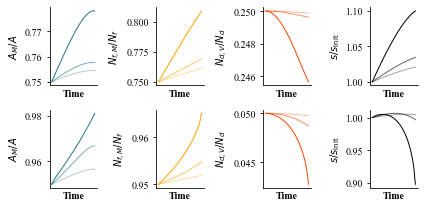

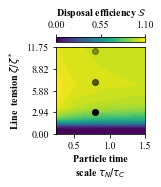

In [63]:
fig, axes = plt.subplots(2, 4, figsize=(6, 3))
fig2, ax2 = plt.subplots(figsize=(1.6, 2))

# --- Heatmap ---
# Load and plot the heatmap
file_path = os.path.join(directory, 'Score_t_n.csv')
df = pd.read_csv(file_path, header=None)
df[1] = df[1]/asize # zeta was rescaled by a/A in Matlab
df[2] = df[2].astype(str).str.extract(r'([+-]?\d+(?:\.\d+)?)')[0].astype(float)
df.loc[df[2]>50,2]=0
plot_contour(ax2, df, 'Particle time\n'+r'scale $\tau_N/\tau_C$')
ax2.set_ylabel(r"Line  tension $\zeta/\zeta^*$", fontweight = 'bold')

zeta = [5, 12, 19]

N=0.5

alpha = 1

for z in zeta:
    print(z/asize/zeta_change)
    file = os.path.join(directory_trajectories, f"Traj_tn_z_0.8_{str(z)}_0.75.csv")
    df = pd.read_csv(file, header = None)
    df[0]=df[0]/df[0].values[-1]
    axes[0,0].plot(df[0].values, df[1].values, color = AMblue, alpha=alpha)
    axes[0,1].plot(df[0].values, 2*df[3].values/N, color = 'orange', alpha=alpha)
    axes[0,2].plot(df[0].values, (1-2*df[4].values/N), color = 'orangered', alpha=alpha)
    axes[0,3].plot(df[0].values, df[5].values/df[5].values[0], color='black', alpha=alpha)
    
    file = os.path.join(directory_trajectories, f"Traj_tn_z_0.8_{str(z)}_0.95.csv")
    df = pd.read_csv(file, header = None)
    df[0]=df[0]/df[0].values[-1]
    
    axes[1,0].plot(df[0].values, df[1].values, color = AMblue, alpha=alpha)
    axes[1,1].plot(df[0].values, 2*df[3].values/N, color = 'orange', alpha=alpha)
    axes[1,2].plot(df[0].values, (1-2*df[4].values/N), color = 'orangered', alpha=alpha)
    axes[1,3].plot(df[0].values, df[5].values/df[5].values[0], color='black', alpha=alpha)
    
    ax2.scatter(0.8, z/asize, color = 'black', marker='o', edgecolor = 'black', zorder=3, alpha = alpha)
    
    alpha *= 0.6

for i in [0,1]:
    axes[i,0].set_xlabel("Time", fontweight='bold')
    axes[i,0].set_ylabel(r"$A_M/A$", fontweight='bold')
    axes[i,1].set_xlabel("Time", fontweight='bold')
    axes[i,1].set_ylabel(r"$N_{f,M}/N_f$", fontweight='bold')
    axes[i,2].set_xlabel("Time", fontweight='bold')
    axes[i,2].set_ylabel(r"$N_{d,V}/N_d$", fontweight='bold')
    axes[i,3].set_xlabel("Time", fontweight='bold')
    axes[i,3].set_ylabel(r"$s/s_\mathrm{init}$", fontweight='bold')
    
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])


# Save plot
fig.tight_layout()
fig.savefig(os.path.join(FIGURES, 'Paper', 'score_traj_tn.svg'), dpi=300)
plt.show(fig)
plt.close(fig)
    
# Save plot
fig2.savefig(os.path.join(FIGURES, 'Paper', 'supp_tn.svg'), dpi=300)
plt.show(fig2)
plt.close(fig2)

3 2.350797802004055
7.5 0.2938497252505069
9 0.2938497252505069


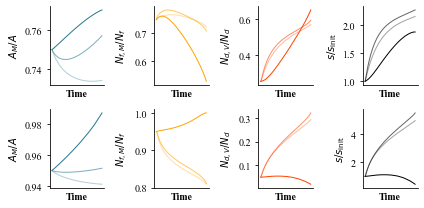

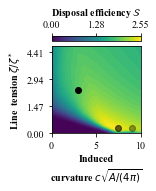

In [67]:
fig, axes = plt.subplots(2, 4, figsize=(6, 3))
fig2, ax2 = plt.subplots(figsize=(1.6, 2))  # Adjust size for a single plot

# Load and plot the heatmap
file_path = os.path.join(directory, 'Score_c.csv')
df = pd.read_csv(file_path, header=None)
df[1] = df[1]/asize # zeta was rescaled by a/A in Matlab
plot_contour(ax2, df, 'Induced\n' + r"curvature $c \sqrt{A/(4\pi)}$")
ax2.set_ylabel(r"Line  tension $\zeta/\zeta^*$", fontweight = 'bold')

combi = [(3, 4), (7.5, 0.5), (9, 0.5)]

N=0.1

alpha = 1

for (c, z) in combi:
    
    print(c, z/asize/zeta_change)
    file = os.path.join(directory_trajectories, f"Traj_c_z_{str(c)}_{str(z)}_0.75.csv")
    df = pd.read_csv(file, header = None)
    df[0]=df[0]/df[0].values[-1]
    axes[0,0].plot(df[0].values, df[1].values, color = AMblue, alpha=alpha)
    axes[0,1].plot(df[0].values, 2*df[3].values/N, color = 'orange', alpha=alpha)
    axes[0,2].plot(df[0].values, (1-2*df[4].values/N), color = 'orangered', alpha=alpha)
    axes[0,3].plot(df[0].values, df[5].values/df[5].values[0], color='black', alpha=alpha)
    
    file = os.path.join(directory_trajectories, f"Traj_c_z_{str(c)}_{str(z)}_0.95.csv")
    df = pd.read_csv(file, header = None)
    df[0]=df[0]/df[0].values[-1]
    
    axes[1,0].plot(df[0].values, df[1].values, color = AMblue, alpha=alpha)
    axes[1,1].plot(df[0].values, 2*df[3].values/N, color = 'orange', alpha=alpha)
    axes[1,2].plot(df[0].values, (1-2*df[4].values/N), color = 'orangered', alpha=alpha)
    axes[1,3].plot(df[0].values, df[5].values/df[5].values[0], color='black', alpha=alpha)
    
    ax2.scatter(c, z/asize, color = 'black', marker='o', edgecolor = 'black', zorder=3, alpha = alpha)
    alpha *= 0.6

for i in [0,1]:
    axes[i,0].set_xlabel("Time", fontweight='bold')
    axes[i,0].set_ylabel(r"$A_M/A$", fontweight='bold')
    axes[i,1].set_xlabel("Time", fontweight='bold')
    axes[i,1].set_ylabel(r"$N_{f,M}/N_f$", fontweight='bold')
    axes[i,2].set_xlabel("Time", fontweight='bold')
    axes[i,2].set_ylabel(r"$N_{d,V}/N_d$", fontweight='bold')
    axes[i,3].set_xlabel("Time", fontweight='bold')
    axes[i,3].set_ylabel(r"$s/s_\mathrm{init}$", fontweight='bold')
    
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])


# Save plot
fig.tight_layout()
fig.savefig(os.path.join(FIGURES, 'Paper', 'score_traj_c.svg'), dpi=300)
plt.show()
plt.close(fig)

# Save plot
fig2.savefig(os.path.join(FIGURES, 'Paper', 'supp_c.svg'), dpi=300)
plt.show(fig2)
plt.close(fig2)

4 0.2
8 0.07
14.4 0.05


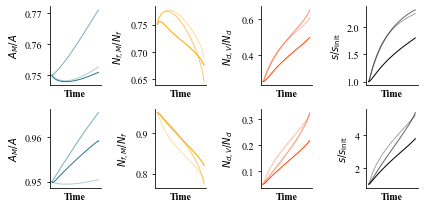

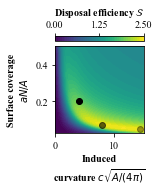

In [69]:
fig, axes = plt.subplots(2, 4, figsize=(6, 3))
fig2, ax2 = plt.subplots(figsize=(1.6, 2))

# Load and plot the heatmap
file_path = os.path.join(directory, 'Score_n_c.csv')
df = pd.read_csv(file_path, header=None)

df_pivot = df.pivot(index=0, columns=1, values=2) # Score

X, Y = np.meshgrid(df_pivot.columns, df_pivot.index)
Z = df_pivot.values

Z_smooth = gaussian_filter(Z, sigma=1)
contour = ax2.contourf(X, Y, Z_smooth, levels=50, cmap='viridis')

for cf in contour.collections:
    cf.set_rasterized(True)

cbar = plt.colorbar(contour, ax=ax2, orientation = 'horizontal', location = 'top')

vmin, vmax = cbar.mappable.get_clim()
cbar.set_ticks(np.linspace(vmin, vmax, 3))
cbar.solids.set_rasterized(True)
cbar.set_label("Disposal efficiency $\mathcal{S}$", fontweight = 'bold')

# Round colorbar ticks to 2 decimal places
cbar.set_ticks(np.round(cbar.get_ticks(), 2))

ax2.set_xlabel("Induced\n"+r"curvature $c\sqrt{A/(4\pi)}$", fontweight = 'bold')
ax2.set_ylabel("Surface coverage\n"+r"$aN/A$", fontweight = 'bold')

######
combi = [(0.2, 4), (0.07, 8), (0.05, 14.4)]

alpha = 1

for (n, c) in combi:
    print(c,n)
    file = os.path.join(directory_trajectories, f"Traj_n_c_{str(n)}_{str(c)}_0.75.csv")
    df = pd.read_csv(file, header = None)
    df[0]=df[0]/df[0].values[-1]
    axes[0,0].plot(df[0].values, df[1].values, color = AMblue, alpha=alpha)
    axes[0,1].plot(df[0].values, 2*df[3].values/n, color = 'orange', alpha=alpha)
    axes[0,2].plot(df[0].values, (1-2*df[4].values/n), color = 'orangered', alpha=alpha)
    axes[0,3].plot(df[0].values, df[5].values/df[5].values[0], color='black', alpha=alpha)
    
    file = os.path.join(directory_trajectories, f"Traj_n_c_{str(n)}_{str(c)}_0.95.csv")
    df = pd.read_csv(file, header = None)
    df[0]=df[0]/df[0].values[-1]
    
    axes[1,0].plot(df[0].values, df[1].values, color = AMblue, alpha=alpha)
    axes[1,1].plot(df[0].values, 2*df[3].values/n, color = 'orange', alpha=alpha)
    axes[1,2].plot(df[0].values, (1-2*df[4].values/n), color = 'orangered', alpha=alpha)
    axes[1,3].plot(df[0].values, df[5].values/df[5].values[0], color='black', alpha=alpha)
    
    ax2.scatter(c, n, color = 'black', marker='o', edgecolor = 'black', zorder=3, alpha = alpha)
    
    alpha *= 0.6

for i in [0,1]:
    axes[i,0].set_xlabel("Time", fontweight='bold')
    axes[i,0].set_ylabel(r"$A_M/A$", fontweight='bold')
    axes[i,1].set_xlabel("Time", fontweight='bold')
    axes[i,1].set_ylabel(r"$N_{f,M}/N_f$", fontweight='bold')
    axes[i,2].set_xlabel("Time", fontweight='bold')
    axes[i,2].set_ylabel(r"$N_{d,V}/N_d$", fontweight='bold')
    axes[i,3].set_xlabel("Time", fontweight='bold')
    axes[i,3].set_ylabel(r"$s/s_\mathrm{init}$", fontweight='bold')
    
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])

# Save plot
fig.tight_layout()
fig.savefig(os.path.join(FIGURES, 'Paper', 'score_traj_c_n.svg'), dpi=300)
plt.show(fig)
plt.close(fig)

fig2.savefig(os.path.join(FIGURES, 'Paper', 'supp_c_N.svg'))
plt.show(fig2)
plt.close(fig2)